<a href="https://colab.research.google.com/github/adi23042008-byte/aiml-bootcamp-2026/blob/main/aiml_bootcamp_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [ ]:

marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")
print("Average:",average)

Class failed
Average: 43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
print(df.columns.tolist())

['student_id', 'attendance_percent', 'assignment_score', 'quiz_score', 'lab_completed', 'total_score', 'eligible']


HOMEWORK

Chart 1: Scatter Plot (Attendance vs. Total Score)
Objective: Help students see if there is a positive correlation between attending class and achieving higher overall grades.

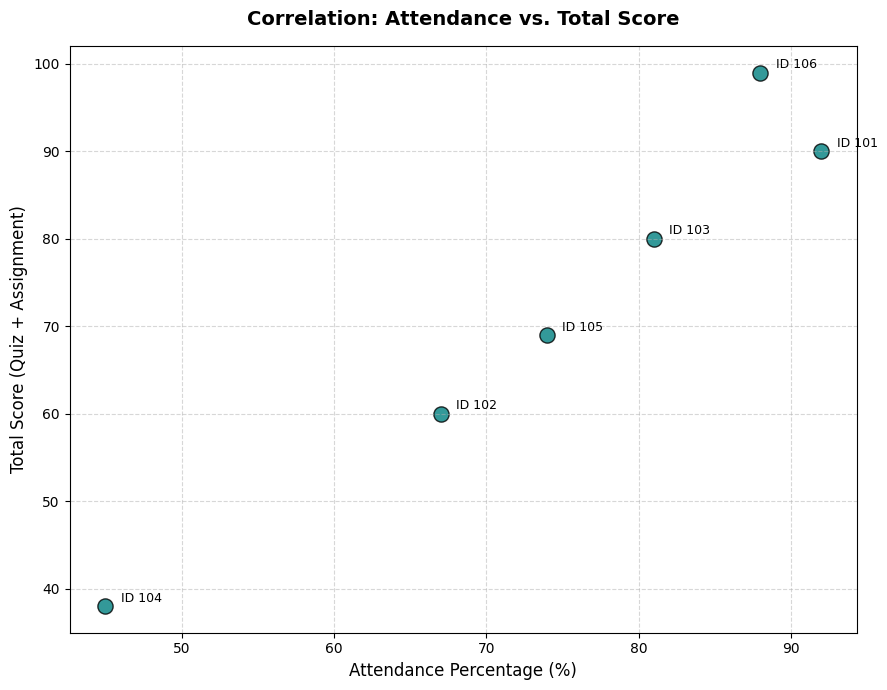

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(df['attendance_percent'], df['total_score'], color='teal', s=120, edgecolor='black', alpha=0.8)
# Annotate each point with the corresponding student ID
for i in range(len(df)):
    plt.annotate(f"ID {df['student_id'].iloc[i]}",
                 (df['attendance_percent'].iloc[i] + 1, df['total_score'].iloc[i] + 0.5),
                 fontsize=9)
plt.title('Correlation: Attendance vs. Total Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attendance Percentage (%)', fontsize=12)
plt.ylabel('Total Score (Quiz + Assignment)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 2: Bar Chart (Lab Completion vs. Average Quiz Score)
Objective: Determine whether students who complete all lab exercises tend to score better on their quizzes.


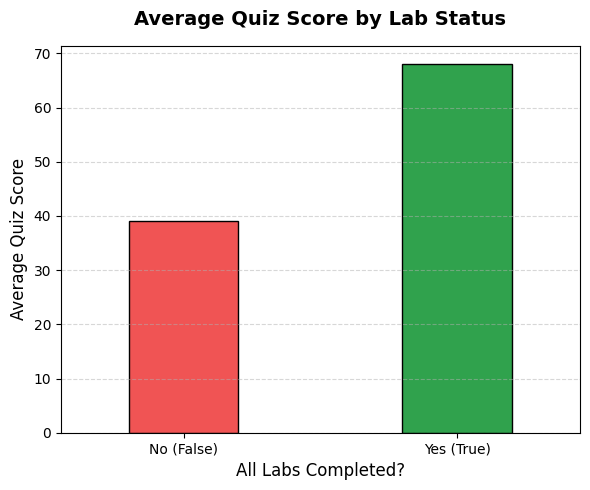

In [ ]:
# Grouping the data to find the average quiz score for each group
avg_quiz_by_lab = df.groupby('lab_completed')['quiz_score'].mean()

plt.figure(figsize=(6, 5))
# Customizing bar colors: Light Crimson for incomplete labs, Soft Mint for completed labs
colors = ['#f05454', '#30a24d']
avg_quiz_by_lab.plot(kind='bar', color=colors, edgecolor='black', width=0.4)

plt.title('Average Quiz Score by Lab Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('All Labs Completed?', fontsize=12)
plt.ylabel('Average Quiz Score', fontsize=12)
plt.xticks([0, 1], ['No (False)', 'Yes (True)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 3: Pie Chart (Distribution of Attendance Categories)
Objective: Use a pie chart to visualize the overall proportion of the class across different attendance bands.

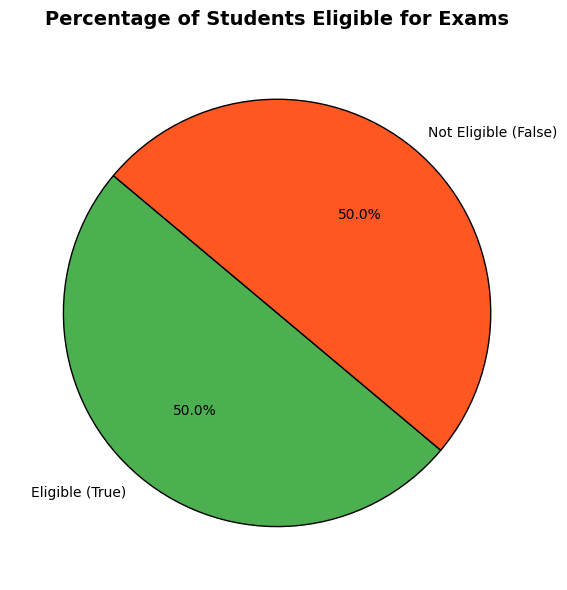

In [ ]:
# 1. Change this line to use your 'eligible' column
eligibility_counts = df['eligible'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(eligibility_counts,
        labels=['Eligible (True)', 'Not Eligible (False)'], # Updated labels to match your data
        autopct='%1.1f%%',
        startangle=140,
        colors=['#4CAF50', '#FF5722'], # Green for True, Red for False
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})

# 2. Update the title to match your feature
plt.title('Percentage of Students Eligible for Exams', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

15 JUNE 2026

In [ ]:
subjects = ["Python", "Math", "AI", "Data"]

In [ ]:
print(subjects)
print(subjects[0])
print(subjects[-1])

['Python', 'Math', 'AI', 'Data']
Python
Data


In [ ]:
college = {
    "college_name": "GLA",
    "section": "CB",
    "city": "Mathura",
    "grades": ["A", "A+", "B", "B+"]
}

In [ ]:
students = [
    {   "name": "Adi Jain",
        "college_name": "GLA",
        "Class": "CB",
        "city": "mathura",
        "grade": "A"
    },
    {
        "name": "Harsh",
        "college_name": "IIT Delhi",
        "Class": "CS",
        "city": "Delhi",
        "grade": "A+"
    },
    {
        "name": "Ashish",
        "college_name": "NIT Trichy",
        "Class": "IT",
        "city": "Tiruchirappalli",
        "grade": "B+"
    },
    {
        "name": "Rahul",
        "college_name": "BHU",
        "Class": "EE",
        "city": "Varanasi",
        "grade": "B"
    },
    {
        "name": "Jagdish",
        "college_name": "DTU",
        "Class": "ME",
        "city": "Delhi",
        "grade": "A"
    }
]
for student in students:
    if student["grade"] == "A+":
        print(student)

{'name': 'Harsh', 'college_name': 'IIT Delhi', 'Class': 'CS', 'city': 'Delhi', 'grade': 'A+'}


In [ ]:
marks = 72

if marks>=80:
  print("distinction")
elif marks>=40 and marks<=79:
  print("pass")
else:
  print('fail')


pass


In [ ]:
if marks %2==0:
    print("even marks")
else:
    print("odd marks")


even marks


In [ ]:
age=int(input())
if age<13:
  print("child")
elif age>13 and age<19:
  print("teenager")
else:
  print("Old")

23
Old


In [ ]:
students_list = [
    {
        "name": "Adi Jain",
        "age": 12,
        "attendance": 92,
        "marks": 85,
        "lab_assignment": True
    },
    {
        "name": "Raj Gupta",
        "age": 15,
        "attendance": 95,
        "marks": 92,
        "lab_assignment": True
    },
    {
        "name": "Rahul Verma",
        "age": 21,
        "attendance": 78,
        "marks": 64,
        "lab_assignment": False
    },
    {
        "name": "Priya Rai",
        "age": 19,
        "attendance":  88,
        "marks": 78,
        "lab_assignment": True
    },
    {
        "name": "Vikram Singh",
        "age": 11,
        "attendance": 60,
        "marks": 45,
        "lab_assignment": False
    }
]
for student in students_list:
    if student["lab_assignment"] == False:
        result = "Lab Assignment Not Submitted"
    elif student["attendance"] < 75:
        result = "Low Attendance"
    elif student["marks"] >= 70:
        result = "Distinction"
    elif student["marks"] >= 40:
        result = "Pass"
    else:
        result = "Fail"

    print(student["name"], "-", result)

Adi Jain - Distinction
Raj Gupta - Distinction
Rahul Verma - Lab Assignment Not Submitted
Priya Rai - Distinction
Vikram Singh - Lab Assignment Not Submitted


16 JUNE 2026


In [ ]:
marks = int(input("Enter marks: "))
def result(marks):
    if marks>=40:
        print("Pass")
    else:
        print("Fail")
result(marks)

Enter marks: 87
Pass


In [ ]:
import numpy as np
marks = np.array([78,84,62])
print(marks+10)

[88 94 72]


In [ ]:
import numpy as np
arr = np.array([10,20,30,40])
print(arr)
print(arr.shape)
matrix = np.array([[10,20,30],
                  [40,50,60]])
print(matrix)
print(matrix.shape)

[10 20 30 40]
(4,)
[[10 20 30]
 [40 50 60]]
(2, 3)


In [ ]:
marks = np.array([78,91,55,72,40,88])
arr_2d = marks.reshape(2, 3)
print(arr_2d)

[[78 91 55]
 [72 40 88]]


In [ ]:
import pandas as pd
df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/session4_dummy_students_data.csv.xls'

In [ ]:
import pandas as pd
df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df['average'] = (df['math'] + df['science'] + df['english']) / 3
top_students = df[df['average'] > 85]
low_attendance = top_students[top_students['attendance_percent'] < 75]
mathura_students = low_attendance[low_attendance['city'] == 'Mathura']
print(df[['name', 'average']])
print(mathura_students)
print(top_students)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/session4_dummy_students_data.csv.xls')
df["average"] = df[["math", "science", "english"]].mean(axis=1)
df["result"] = np.where(df["average"] >= 40, "Pass", "Fail")

class_avg = df["average"].mean()
print(f"Class Average: {class_avg:.2f}")

highest_avg = df["average"].max()
lowest_avg = df["average"].min()
print(f"Highest Average: {highest_avg:.2f}")
print(f"Lowest Average: {lowest_avg:.2f}")

top_students = df[df["average"] == highest_avg]
print("Top Student(s) ")
print(top_students[["name", "average"]])

low_attendance = df[df["attendance_percent"] < 75]
print("Students with Attendance Below 75% ")
print(low_attendance[["name", "attendance_percent"]])

few_assignments = df[df["assignments_submitted"] < 6]
print("Students with Fewer Than 6 Assignments")
print(few_assignments[["name", "assignments_submitted"]])

df.to_csv('session4_student_report.csv', index=False)
print("File saved successfully as 'session4_student_report.csv'")

• Find the average final_project_score. • Find students with study_hours_per_week greater than 8. • Compare average marks of Mumbai students and Pune students. • Create a new column called performance_level. • Save only selected columns to a new CSV.

HOMEWORK

In [ ]:
avg_project = df['final_project_score'].mean()
print("Average Final Project Score:", round(avg_project, 2))

In [ ]:
students = df[df['study_hours_per_week'] > 8]
print("Students who study more than 8 hours per week:")
print(students[['name', 'study_hours_per_week']])

In [ ]:
df['average'] = (df['math'] + df['science'] + df['english']) / 3

mumbai_avg = df[df['city'] == 'Mumbai']['average'].mean()
pune_avg = df[df['city'] == 'Pune']['average'].mean()

print("Mumbai Average:", round(mumbai_avg, 2))
print("Pune Average:", round(pune_avg, 2))

In [ ]:
df['performance_level'] = df['average'].apply(
    lambda x: 'Excellent' if x >= 80
    else 'Good' if x >= 60
    else 'Needs Improvement'
)

print(df[['name', 'average', 'performance_level']])

In [ ]:
new_df = df[['name', 'city', 'average', 'performance_level']]
new_df.to_csv('student_performance.csv', index=False)

print("File saved successfully as 'student_performance.csv'")

17 JUNE 2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


In [ ]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)

In [ ]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())

In [ ]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


In [ ]:
import pandas as pd

# 1. Load the dataset from the remote URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Extract and print basic statistics
# Year Range
min_year = df['year'].min()
max_year = df['year'].max()

# Number of Unique Countries
num_countries = df['country'].nunique()

# Number of Unique Continents
num_continents = df['continent'].nunique()

# 3. Output the results
print(f"Year Range: {min_year} to {max_year}")
print(f"Number of unique countries: {num_countries}")
print(f"Number of unique continents: {num_continents}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Identify the latest year and filter the data
latest_year = df['year'].max()
latest_df = df[df['year'] == latest_year]

# 3. Calculate average life expectancy per continent and sort them
continent_life = latest_df.groupby("continent")["lifeExp"].mean().sort_values()

# 4. Create the Bar Chart
plt.bar(continent_life.index, continent_life.values, color='skyblue', edgecolor='black')

# 5. Add details and labels
plt.title(f"Average Life Expectancy by Continent in {latest_year}", fontsize=12, fontweight='bold')
plt.xlabel("Continent", fontsize=10)
plt.ylabel("Average Life Expectancy (Years)", fontsize=10)
plt.xticks(rotation=45)

# 6. Optimize and display
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Define the target countries
# Note: The dataset labels the USA as 'United States'
target_countries = ['India', 'China', 'United States']

# 3. Filter the DataFrame for only these three countries
filtered_df = df[df['country'].isin(target_countries)]

# 4. Initialize the plot figure
plt.figure(figsize=(10, 6))

# 5. Loop through each country to plot its line individually
colors = {'India': '#FF9933', 'China': '#DE2910', 'United States': '#002868'}
markers = {'India': 'o', 'China': 's', 'United States': '^'}

for country in target_countries:
    # Isolate data for the specific country
    country_data = filtered_df[filtered_df['country'] == country]

    # Plot year vs life expectancy
    plt.plot(
        country_data['year'],
        country_data['lifeExp'],
        marker=markers[country],
        linewidth=2.5,
        color=colors[country],
        label=country
    )

# 6. Customize chart elements
plt.title('Life Expectancy Over Time (1952-2007)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Life Expectancy (Years)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure all recorded data years show explicitly on the x-axis
plt.xticks(filtered_df['year'].unique())

# Add a legend to distinguish the lines
plt.legend(title='Country', fontsize=11, title_fontsize=12, loc='upper left')

# 7. Optimize layout and display
plt.tight_layout()
plt.show()

Life expectancy in China fell sharply between 1960 and 1962 due to the Great Chinese Famine.



The drop in life expectancy in 1959–1961 was caused by mass starvation, disease, and social disruption resulting from the Great Leap Forward’s policy failures, poor agricultural management, and adverse weather, leading to 15–30 million excess deaths

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# 1. Load the dataset from the remote URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# 2. Filter for the latest year (2007) to capture the modern global snapshot
latest_year = df['year'].max()
latest_df = df[df['year'] == latest_year]

# 3. Configure layout options without using .figure()
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# 4. Generate the scatter plot
# Colors indicate continents; size can optionally represent population
ax = sns.scatterplot(
    data=latest_df,
    x='gdpPercap',
    y='lifeExp',
    hue='continent',
    size='pop',
    sizes=(40, 400),
    alpha=0.75,
    edgecolor='w'
)

# 5. Apply a Logarithmic Scale to the X-axis (GDP per capita increases exponentially)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ScalarFormatter())

# Clean up horizontal labels to avoid scientific notation formatting
plt.xticks(
    [500, 1000, 2000, 5000, 10000, 20000, 50000],
    ['500', '1,000', '2,000', '5,000', '10,000', '20,000', '50,000']
)

# 6. Titles and Axes Labels
plt.title(f'GDP per Capita vs. Life Expectancy ({latest_year})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('GDP per Capita (USD, Log Scale)', fontsize=11, labelpad=10)
plt.ylabel('Life Expectancy (Years)', fontsize=11, labelpad=10)

# Move the legend outside or position inside neatly
plt.legend(title='Demographics', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# 7. Final adjustments and rendering
plt.tight_layout()
plt.show()

Life expectancy increased steadily in India, China, and the United States from 1952 to 2007.
The United States maintained the highest life expectancy throughout the period.

indicates improvements in health, living conditions, and socioeconomic development over time.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
student_a = np.array([6 ,85 ,78])
student_b = np.array([3,70,55])
print("Student a vector:" , student_a)
print("Student b vector:" , student_b)

Student a vector: [ 6 85 78]
Student b vector: [ 3 70 55]


In [ ]:
students = pd.DataFrame({

"name": ["Aarav", "Riya", "Kabir", "Meera", "Dev", "Sara"],
"study_hours": [6, 3, 8, 2, 5, 7],
"attendance": [85, 70, 90, 60, 78, 92],
"previous_marks": [78, 55, 88, 35, 65, 84],
"final_marks": [82, 58, 91, 40, 70, 88]

})

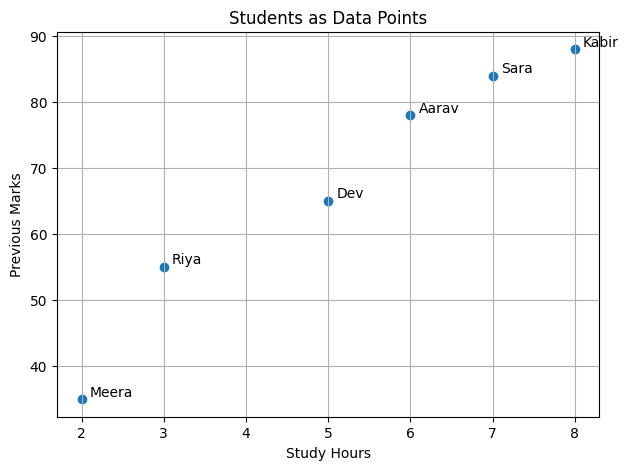

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter( students["study_hours"], students["previous_marks"]

)

for i, row in students.iterrows():
  plt.text(row["study_hours"] + 0.1, row["previous_marks"] + 0.5, row["name"])

plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Students as Data Points")
plt.grid(True)
plt.show()

In [ ]:
point_a = np.array([6,78])
point_b = np.array([3,55])
distance = np.sqrt((point_a[0]-point_b[0])**2 +(point_a[1]-point_b[1])**2)
print("Distance between A and B : ",distance)

Distance between A and B :  23.194827009486403


In [ ]:
feature_columns = ["study_hours","attendance","previous_marks"]
student_vectors = students[feature_columns].values
print(student_vectors)

[[ 6 85 78]
 [ 3 70 55]
 [ 8 90 88]
 [ 2 60 35]
 [ 5 78 65]
 [ 7 92 84]]


each row is 1 student and each column is 1 feature

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix  = cosine_similarity(student_vectors)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index = students["name"],
    columns = students["name"]
)
similarity_df

name,Aarav,Riya,Kabir,Meera,Dev,Sara
name,,,,,,
Aarav,1.000000,0.996913,0.999434,0.976875,0.998860,0.999988
Riya,0.996913,1.000000,0.993724,0.990505,0.999467,0.997017
Kabir,0.999434,0.993724,1.000000,0.969344,0.996756,0.999391
Meera,0.976875,0.990505,0.969344,1.000000,0.985958,0.977304
Dev,0.998860,0.999467,0.996756,0.985958,1.000000,0.998956
Sara,0.999988,0.997017,0.999391,0.977304,0.998956,1.000000


In [ ]:
sentence = "The movie was not good"
tokens = sentence.lower().split()
print(tokens)

['the', 'movie', 'was', 'not', 'good']


In [ ]:
vocab = {
    "the":1,
    "movie":2,
    "was":3,
    "not":4,
    "good":5
}
token_ids = [vocab[word] for word in tokens]
print(token_ids)

[1, 2, 3, 4, 5]


In [ ]:
sentences=[

"dog bites man",
"man bites dog",
"the movie was good",
"the movie was not good"
]

for sentence in sentences:
  print(sentence,"->", sentence.split())

dog bites man -> ['dog', 'bites', 'man']
man bites dog -> ['man', 'bites', 'dog']
the movie was good -> ['the', 'movie', 'was', 'good']
the movie was not good -> ['the', 'movie', 'was', 'not', 'good']


In [ ]:
positive_words = ["good", "great", "amazing", "excellent", "love"]
negative_words = ["bad", "terrible", "poor", "hate", "boring"]
def simple_sentiment(sentence):
  words = sentence.lower().replace(".", "").split()
  score = 0
  for word in words:

    if word in positive_words:
      score += 1
    elif word in negative_words:
      score - 1

  if score > 0:
    return "Positive"
  elif score < 0:
    return "Negative"
  else:
    return "Neutral"
print(simple_sentiment("The movie was good"))
print(simple_sentiment("The movie was bad"))
print(simple_sentiment("The movie was not good"))


Positive
Neutral
Positive


In [ ]:
positive_words = ["good", "great", "excellent", "amazing", "love"]
negative_words = ["bad", "terrible", "awful", "worst", "hate"]

def better_sentiment_with_not(sentence):
    # Split the sentence into lowercase words and remove periods
    words = sentence.lower().replace(".", "").split()
    score = 0

    for i, word in enumerate(words):
        # Safely get the previous word if it exists
        previous_word = words[i - 1] if i > 0 else ""

        if word in positive_words:
            if previous_word == "not":
                score -= 1
            else:
                score += 1
        elif word in negative_words:
            if previous_word == "not":
                score += 1
            else:
                score -= 1

    # Determine final sentiment based on score
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

# Testing the function
print(better_sentiment_with_not("The movie was good"))      # Output: Positive
print(better_sentiment_with_not("The movie was not good"))  # Output: Negative
print(better_sentiment_with_not("The movie was not bad"))   # Output: Positive

Positive
Negative
Positive


In [1]:
sentence = "the movie was not good"
tokens = sentence.split()

memory = ""

for token in tokens:
    memory = memory + token + " "
    print("Current token:", token)
    print("Memory so far:", memory.strip())
    print("--------------------")

Current token: the
Memory so far: the
--------------------
Current token: movie
Memory so far: the movie
--------------------
Current token: was
Memory so far: the movie was
--------------------
Current token: not
Memory so far: the movie was not
--------------------
Current token: good
Memory so far: the movie was not good
--------------------


In [2]:
sentence = "the movie was not good"

tokens = sentence.split()

hidden_state = {
    "topic": None,
    "negation_active": False,
    "sentiment_word": None
}

for token in tokens:
    if token in ["movie", "food", "product"]:
        hidden_state["topic"] = token

    if token == "not":
        hidden_state["negation_active"] = True

    if token in ["good", "bad", "great", "terrible"]:
        hidden_state["sentiment_word"] = token

    print("Token:", token)
    print("Hidden state:", hidden_state)
    print("-----")

Token: the
Hidden state: {'topic': None, 'negation_active': False, 'sentiment_word': None}
-----
Token: movie
Hidden state: {'topic': 'movie', 'negation_active': False, 'sentiment_word': None}
-----
Token: was
Hidden state: {'topic': 'movie', 'negation_active': False, 'sentiment_word': None}
-----
Token: not
Hidden state: {'topic': 'movie', 'negation_active': True, 'sentiment_word': None}
-----
Token: good
Hidden state: {'topic': 'movie', 'negation_active': True, 'sentiment_word': 'good'}
-----


In [4]:
import tensorflow as tf
from tensorflow.keras import layers

vocab_size = 1000
embedding_dim = 16
sequence_length = 8

simple_rnn_model = tf.keras.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=sequence_length
    ),
    layers.SimpleRNN(32),
    layers.Dense(1, activation="sigmoid")
])

simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

firstly, import all the important libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [ ]:
sentences = [
    "In a solitary style and crash the cemetery gates",
    "I have been waiting for this",
    "The weather is terrible"
]

In [ ]:
tokenizer = Tokenizer()

In [ ]:
tokenizer.fit_on_texts(sentences)

In [ ]:
print(tokenizer.word_index)

{'the': 1, 'in': 2, 'a': 3, 'solitary': 4, 'style': 5, 'and': 6, 'crash': 7, 'cemetery': 8, 'gates': 9, 'i': 10, 'have': 11, 'been': 12, 'waiting': 13, 'for': 14, 'this': 15, 'weather': 16, 'is': 17, 'terrible': 18}


In [ ]:
sequences = tokenizer.texts_to_sequences(sentences)

print(sequences)

[[2, 3, 4, 5, 6, 7, 1, 8, 9], [10, 11, 12, 13, 14, 15], [1, 16, 17, 18]]


In [ ]:
padded_sequences = pad_sequences(sequences, padding='post')

print(padded_sequences)

[[ 2  3  4  5  6  7  1  8  9]
 [10 11 12 13 14 15  0  0  0]
 [ 1 16 17 18  0  0  0  0  0]]


In [ ]:
embedding_layer = tf.keras.layers.Embedding(
    input_dim=len(tokenizer.word_index)+1,
    output_dim=8
)

In [ ]:
embeddings = embedding_layer(padded_sequences)

print(embeddings)

tf.Tensor(
[[[ 0.01839748  0.02479614  0.04666011  0.00380862  0.03298794
    0.04343574 -0.03951753  0.01142572]
  [ 0.02982743 -0.00517078 -0.02181244  0.02201651  0.00438926
   -0.01028465  0.00654408 -0.02132574]
  [ 0.03919479 -0.030486    0.00842481 -0.01212608  0.03428629
    0.03176602  0.03911861  0.03357306]
  [-0.0478723   0.02163829  0.0319216   0.02753532 -0.00396155
   -0.0096429  -0.02711172 -0.01848844]
  [-0.03167024 -0.03833138  0.01537124 -0.02540854  0.01240083
   -0.04899437 -0.02677993 -0.02536159]
  [ 0.02986049  0.01948235 -0.03197407  0.03623158 -0.03299437
    0.00395812  0.00814385 -0.03922904]
  [ 0.02318319 -0.00901188  0.025576    0.03595154 -0.00959541
    0.03031529  0.03087672 -0.03114929]
  [ 0.03811425 -0.04870028 -0.02757288  0.02149668  0.02884299
    0.03542961  0.02269698  0.018551  ]
  [ 0.03367433 -0.01345866 -0.03482345  0.02754143  0.01493334
   -0.03506154 -0.04726001  0.01795167]]

 [[ 0.03453476  0.03768071 -0.00082676  0.00096277 -0.017467

In [ ]:
labels = np.array([1,1,0])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=8
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    padded_sequences,
    labels,
    epochs=30
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 0.6923
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6667 - loss: 0.6905
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6667 - loss: 0.6891
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6667 - loss: 0.6880
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.6869
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.6859
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.6850
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.6841
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.6831
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.6822
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.6812
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.6802
Epo

In [ ]:
new_sentence = [
    "the awful things that i have seen"
]

new_sequence = tokenizer.texts_to_sequences(new_sentence)

new_padded = pad_sequences(
    new_sequence,
    maxlen=padded_sequences.shape[1],
    padding='post'
)

prediction = model.predict(new_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [ ]:
if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")

Positive


current input = x_t
previous memory = h_(t-1)
new memory = h_t
output = y_t